# Post Data Analysis

This is the final stage of the project before transitioning to group tasks. Before continuing, make sure you have trained around `40` model combinations, covering all model types (`MyNN`, `NN`, `RNN`, `LSTM`, and `GRU`).
The provided code will generate three plots:

- __Training Loss Comparison__ – This plot shows the training loss for each model combination, helping you identify which combination achieved the lowest train loss.
- __Evaluation Metrics Comparison__ – This plot compares all metrics across all model combinations, allowing you to determine which model performed best overall.
- __Predictions vs. Target Values__ – This plot visualizes how the predicted values compare to the actual target values, helping you assess how well the model fits the data.

Now, skip the `Do Not Edit` cell, generate the plots, and complete the analysis tasks. To generate all three plots, you will need to update the variables appropriately based on the `# TODO` instructions.

In [52]:
# ------------------- #
# --- Do Not Edit --- #
# ------------------- #

import os
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import defaultdict

class ModelTrainingLossVisualizer:
    def __init__(self, base_path, datasets, models, activations, optimizers, epochs):
        self.base_path = base_path
        self.datasets = datasets
        self.models = models
        self.activations = activations
        self.optimizers = optimizers
        self.epochs_options = epochs

    def load_training_losses(self):
        losses = defaultdict(lambda: defaultdict(list))

        for dataset in self.datasets:
            for model in self.models:
                for activation in self.activations:
                    for optimizer in self.optimizers:
                        for epoch in self.epochs_options:
                            folder = os.path.join(
                                self.base_path,
                                dataset,
                                model,
                                activation,
                                optimizer,
                                f"epochs-{epoch}"
                            )
                            path = os.path.join(folder, "train_loss.json")
                            if not os.path.isfile(path):
                                continue
                            try:
                                with open(path, "r") as f:
                                    data = json.load(f)
                                loss_series = [entry["loss"] for entry in data["train_loss"]]
                                label = f"{activation}-{optimizer}-{epoch}"
                                losses[dataset][model].append((label, loss_series))
                            except Exception as e:
                                print(f"Error reading {path}: {e}")
        return losses

    def plot_training_loss_by_model(self, losses):
        colors = sns.color_palette("tab10")

        for dataset, model_data in losses.items():
            print(f"\nDataset: {dataset}")
            for model, loss_lists in model_data.items():
                if not loss_lists:
                    continue
                plt.figure(figsize=(10, 5), dpi=120)
                for i, (label, loss_series) in enumerate(loss_lists):
                    color = colors[i % len(colors)]
                    plt.plot(
                        range(1, len(loss_series) + 1),
                        loss_series,
                        label=label,
                        color=color,
                        marker='o',
                        markersize=4,
                        linewidth=1.5
                    )
                plt.title(f"{dataset.upper()} - {model} Training Loss", fontsize=14)
                plt.xlabel("Epoch", fontsize=12)
                plt.ylabel("Loss", fontsize=12)
                plt.xticks(fontsize=10)
                plt.yticks(fontsize=10)
                plt.legend(fontsize="small", frameon=True, framealpha=0.9, loc="best")
                plt.grid(True, linestyle="--", alpha=0.5)
                plt.tight_layout()
                plt.show()

class ModelEvaluationMetricsVisualizer:
    def __init__(self, base_path, datasets, models, activations, optimizers, epochs):
        self.base_path = base_path
        self.datasets = datasets
        self.models = models
        self.activations = activations
        self.optimizers = optimizers
        self.epochs_options = epochs

    def load_evaluation_metrics(self):
        metrics_data = defaultdict(list)

        for dataset in self.datasets:
            for model in self.models:
                for activation in self.activations:
                    for optimizer in self.optimizers:
                        for epoch in self.epochs_options:
                            folder = os.path.join(
                                self.base_path,
                                dataset,
                                model,
                                activation,
                                optimizer,
                                f"epochs-{epoch}"
                            )
                            path = os.path.join(folder, "evaluate_model.json")
                            if not os.path.isfile(path):
                                continue
                            try:
                                with open(path, "r") as f:
                                    data = json.load(f)
                                label = f"{model}-{activation}-{optimizer}-{epoch}"
                                metrics_data[dataset].append({
                                    "model": model,
                                    "label": label,
                                    "mae": data["mae"],
                                    "rmse": data["rmse"],
                                    "r2": data["r2"]
                                })
                            except Exception as e:
                                print(f"Error reading {path}: {e}")
        return metrics_data

    def plot_metrics_by_dataset(self, metrics_data):
        for dataset, items in metrics_data.items():
            if not items:
                continue

            print(f"\nDataset: {dataset}")
            sns.set(style="whitegrid")
            metric_names = ["mae", "rmse", "r2"]

            for metric in metric_names:
                labels = [item["label"] for item in items]
                values = [item[metric] for item in items]
                plt.figure(figsize=(14, 6), dpi=120)
                sns.barplot(x=labels, y=values, palette="Set2")
                plt.title(f"{dataset.upper()} - {metric.upper()} Across Configurations", fontsize=14)
                plt.xlabel("Model-Activation-Optimizer-Epoch", fontsize=12)
                plt.ylabel(metric.upper(), fontsize=12)
                plt.xticks(rotation=45, ha="right", fontsize=9)
                plt.yticks(fontsize=10)
                plt.tight_layout()
                plt.grid(True, axis="y", linestyle="--", alpha=0.5)
                plt.show()

class ForecastPlotter:
    def __init__(self, base_path, dataset, model, activation, optimizer, epochs):
        self.pred_path = os.path.join(
            base_path,
            dataset,
            model,
            activation,
            optimizer,
            f"epochs-{epochs}",
            "predictions.json"
        )
        self.data = self._load_predictions()

    def _load_predictions(self):
        if not os.path.isfile(self.pred_path):
            print(f"File not found: {self.pred_path}")
            return None
        with open(self.pred_path, "r") as f:
            return json.load(f)

    def _set_plot_style(self):
        plt.style.use("seaborn-v0_8-muted")
        plt.rcParams.update({
            "font.size": 13,
            "axes.labelsize": 14,
            "axes.titlesize": 15,
            "legend.fontsize": 12,
            "xtick.labelsize": 11,
            "ytick.labelsize": 11
        })

    def get_num_forecast_indices(self, building_id):
        if self.data is None or building_id not in self.data:
            print(f"Missing data or building '{building_id}' not found.")
            return 0
        num = len(self.data[building_id]["predictions"])
        print(f"Building '{building_id}' has {num} forecast indices.")
        return num

    def plot_forecast_chain(self, building_id, index=0):
        if self.data is None or building_id not in self.data:
            print(f"Missing data or building '{building_id}' not found.")
            return

        self._set_plot_style()

        load = np.squeeze(np.array(self.data[building_id]["load"][index]))
        predictions = np.squeeze(np.array(self.data[building_id]["predictions"][index]))
        targets = np.squeeze(np.array(self.data[building_id]["targets"][index]))

        x_load = np.arange(len(load))
        x_future = np.arange(len(load), len(load) + len(predictions))
        full_target = np.concatenate([load, targets])
        x_target = np.arange(len(full_target))

        plt.figure(figsize=(14, 5))
        plt.plot(x_target, full_target, label="Actual (Load + Target)", linewidth=2.5, color="#4C72B0")
        plt.plot(x_future, predictions, label="Predicted", linewidth=2.5, color="#DD8452")
        plt.title(f"{building_id} | Forecast Chain | Index: {index}")
        plt.xlabel("Hours")
        plt.ylabel("Energy Usage (kWh)")
        plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
        plt.legend(frameon=False)
        plt.tight_layout(pad=2)
        plt.show()

    def plot_predicted_vs_target_only(self, building_id, index=0):
        if self.data is None or building_id not in self.data:
            print(f"Missing data or building '{building_id}' not found.")
            return

        self._set_plot_style()

        predictions = np.squeeze(np.array(self.data[building_id]["predictions"][index]))
        targets = np.squeeze(np.array(self.data[building_id]["targets"][index]))

        if predictions.shape != targets.shape:
            print("Shape mismatch between predicted and target.")
            return

        x = np.arange(len(predictions))

        plt.figure(figsize=(12, 5))
        plt.plot(x, targets, label="Actual Target", linewidth=2.5, color="#4C72B0")
        plt.plot(x, predictions, label="Predicted", linewidth=2.5, color="#DD8452")
        plt.title(f"{building_id} | Predicted vs Target | Index: {index}")
        plt.xlabel("Hours")
        plt.ylabel("Energy Usage (kWh)")
        plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
        plt.legend(frameon=False)
        plt.tight_layout(pad=2)
        plt.show()

# ------------------- #
# --- Do Not Edit --- #
# ------------------- #

## Plot: Training Loss Comparison


Dataset: borealis


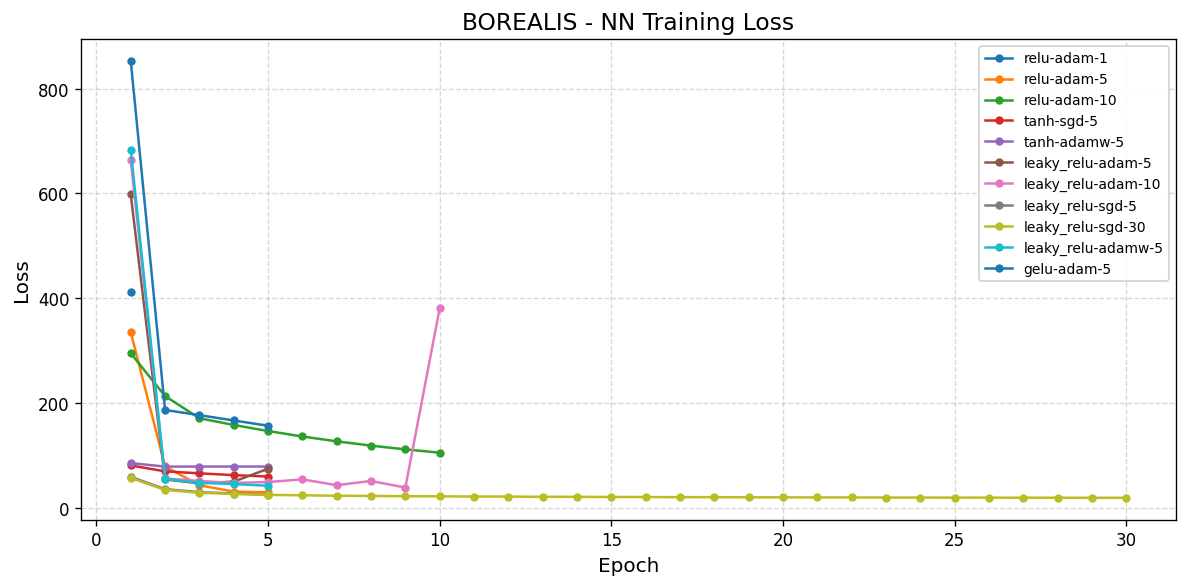

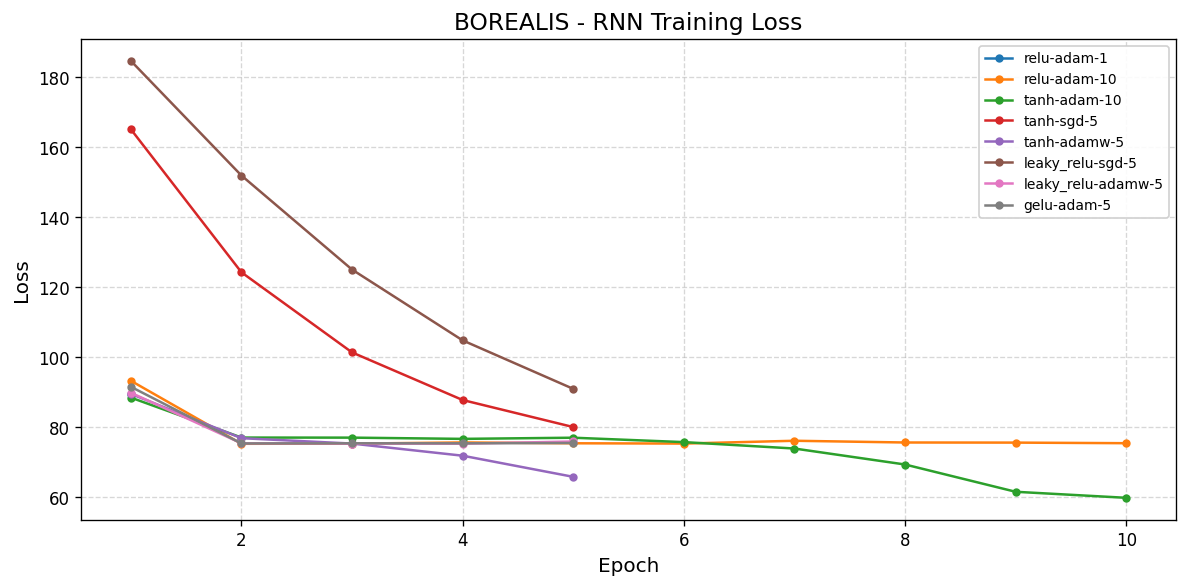

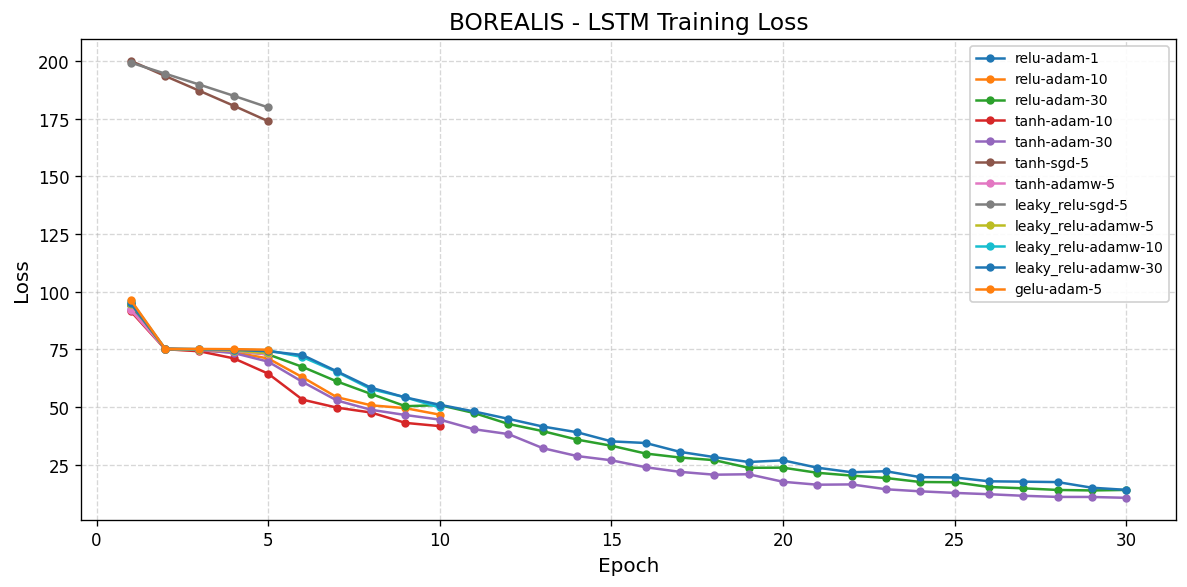

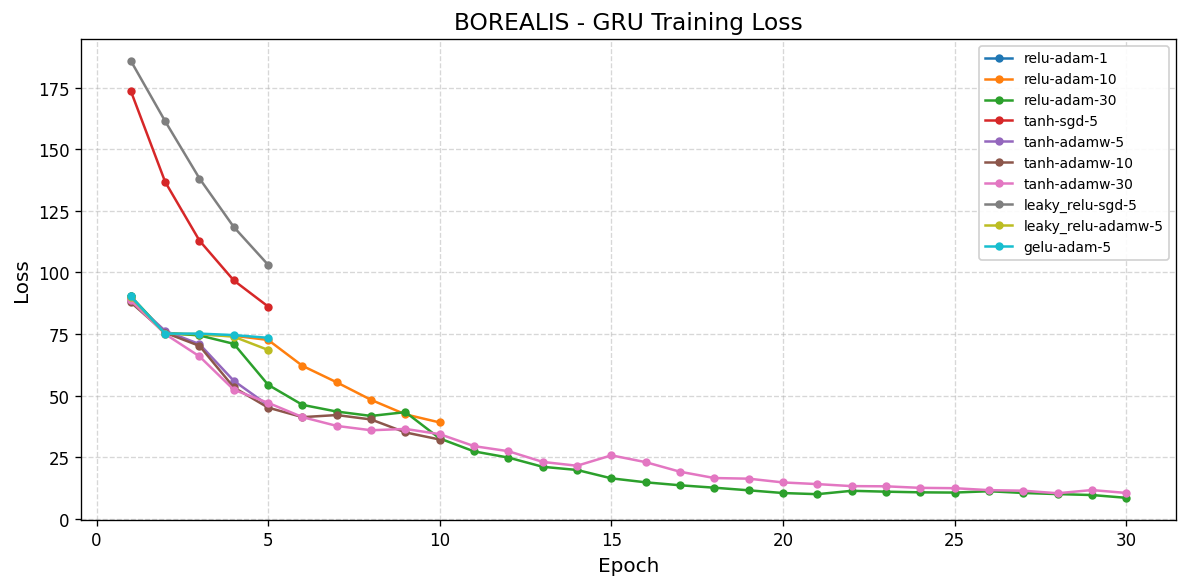

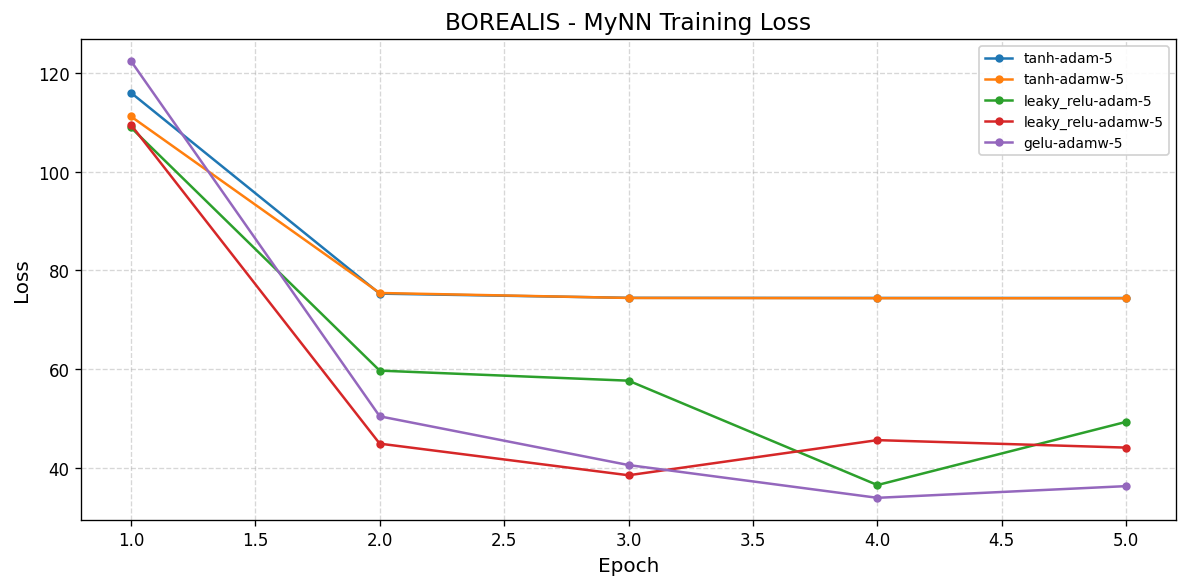

In [4]:
# ------------------- #
# ------ Edit ------- #
# ------------------- #

if __name__ == "__main__":
    visualizer = ModelTrainingLossVisualizer(
        base_path=os.getcwd(), 
        datasets= ["borealis"], # TODO: Provide the dataset name as a list using the format [dataset_name]
        models = ["NN", "RNN", "LSTM", "GRU", "MyNN"],
        activations = ["relu", "tanh", "leaky_relu", "gelu"],
        optimizers = ["adam", "sgd", "adamw"],
        epochs = [1, 5, 10, 30]
    )
    losses = visualizer.load_training_losses()
    visualizer.plot_training_loss_by_model(losses)

# ------------------- #
# ------ Edit ------- #
# ------------------- #

## Plot: Overall Metrics Comparison


Dataset: borealis


/tmp/ipykernel_995104/341096253.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette="Set2")


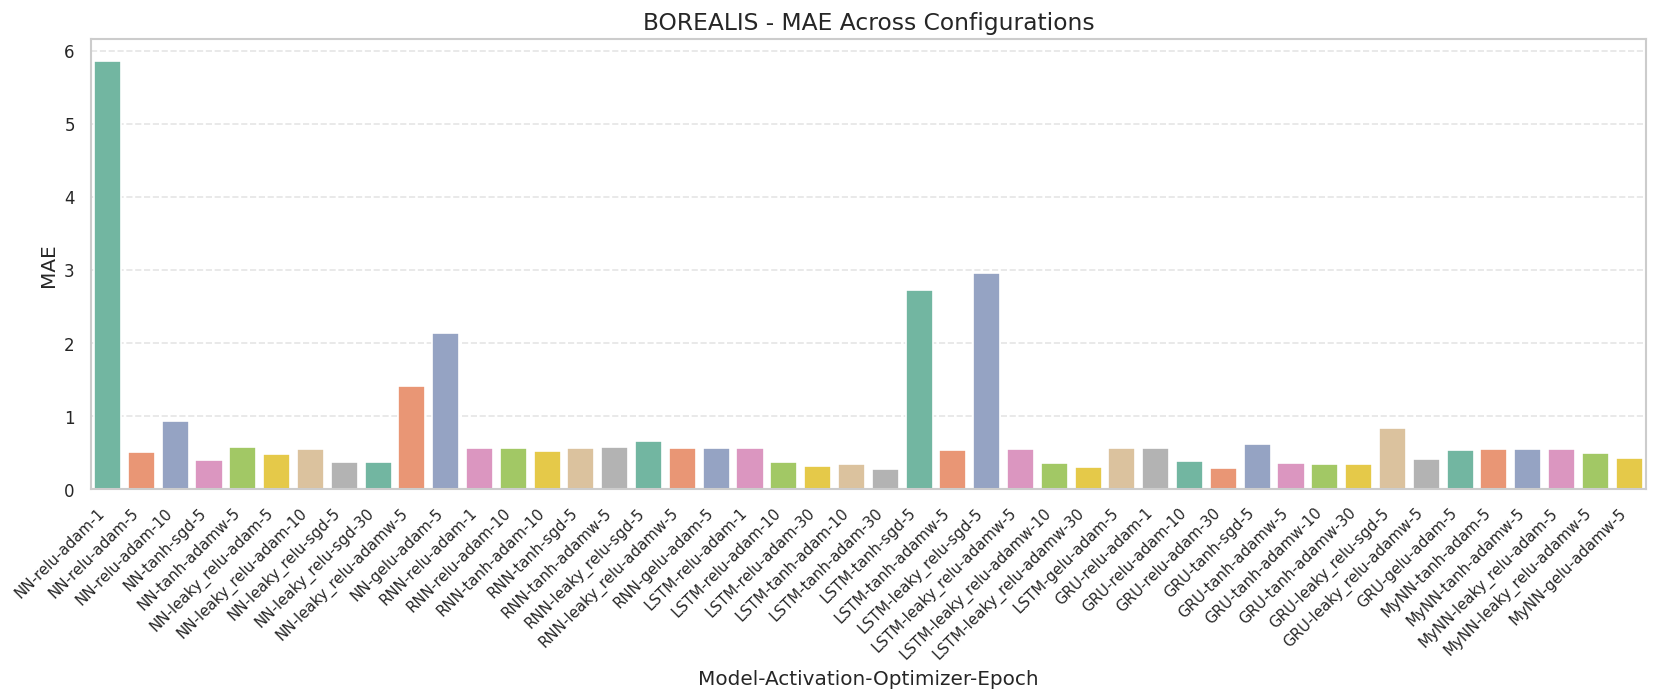

/tmp/ipykernel_995104/341096253.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette="Set2")


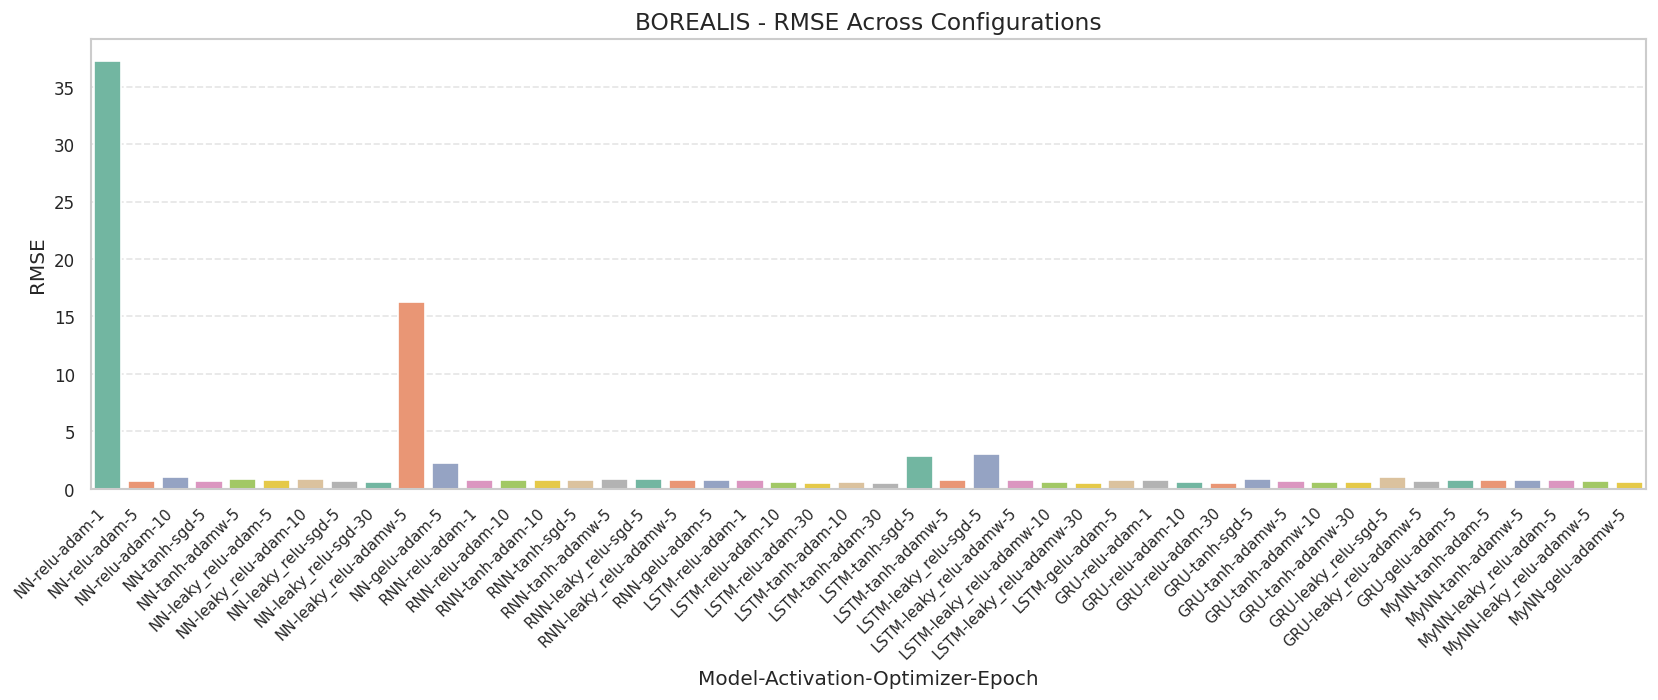

/tmp/ipykernel_995104/341096253.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette="Set2")


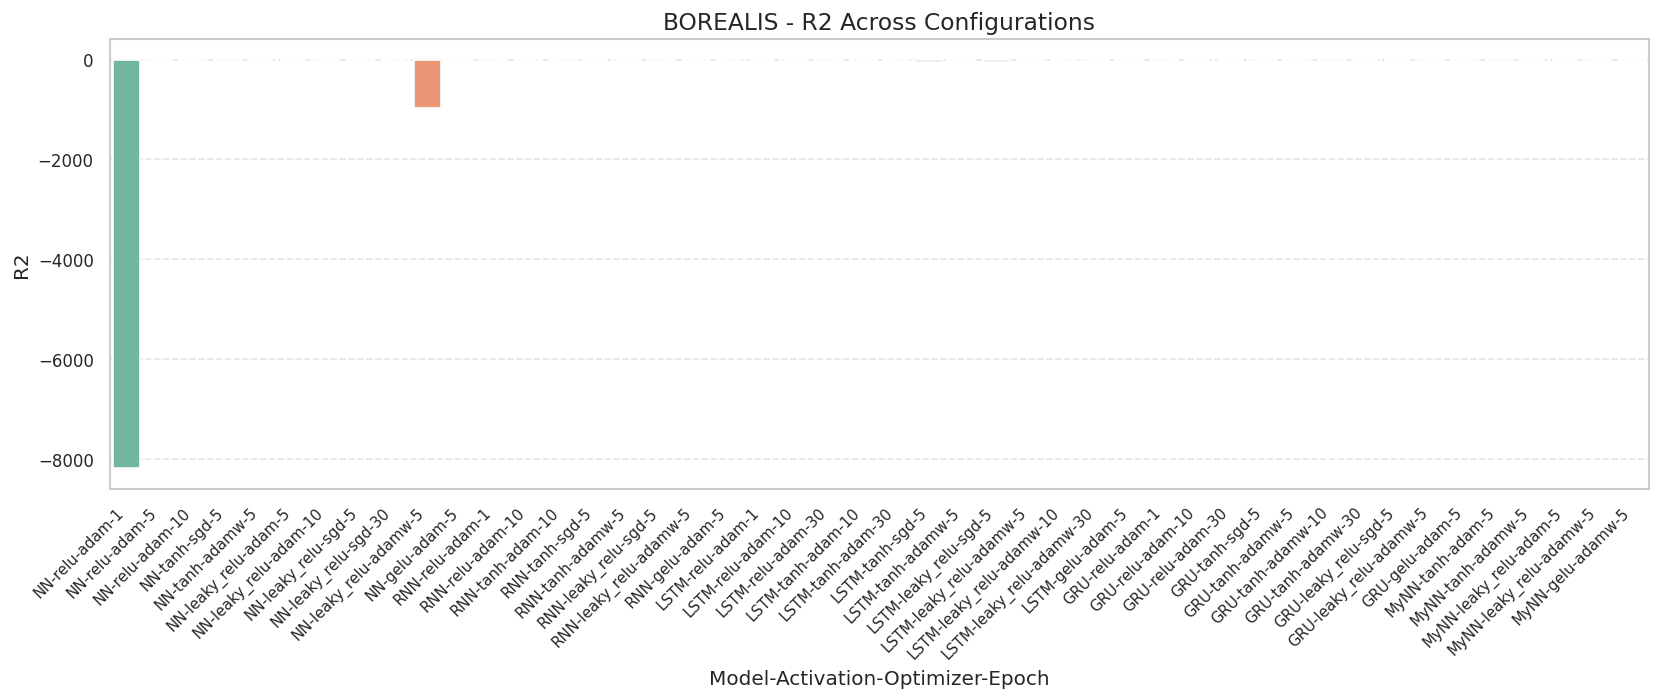

In [54]:
# ------------------- #
# ------ Edit ------- #
# ------------------- #

if __name__ == "__main__":
    visualizer = ModelEvaluationMetricsVisualizer(
        base_path=os.path.join(os.getcwd()), # TODO: 
        datasets= ["borealis"], # TODO: Provide the dataset name as a list using the format [dataset_name] 
        models = ["NN", "RNN", "LSTM", "GRU", "MyNN"],
        activations = ["relu", "tanh", "leaky_relu", "gelu"],
        optimizers = ["adam", "sgd", "adamw"],
        epochs = [1, 5, 10, 30],
    )

    metrics = visualizer.load_evaluation_metrics()
    visualizer.plot_metrics_by_dataset(metrics)

# ------------------- #
# ------ Edit ------- #
# ------------------- #

## Plot: Predicted vs Target

Visualize the predictions for at least five distinct building IDs and compare how the predictions from each model align with the corresponding target values. For this plot, instead of providing variables in a list, you will need to provide individual values as strings, as shown in the example below.

```
dataset = "ideal" 
model = "NN"
activation = "relu"
optimizer = "adam"
epochs = 1
building_id = "home241"
index = 10
```

Building 'home7' has 171 forecast indices.


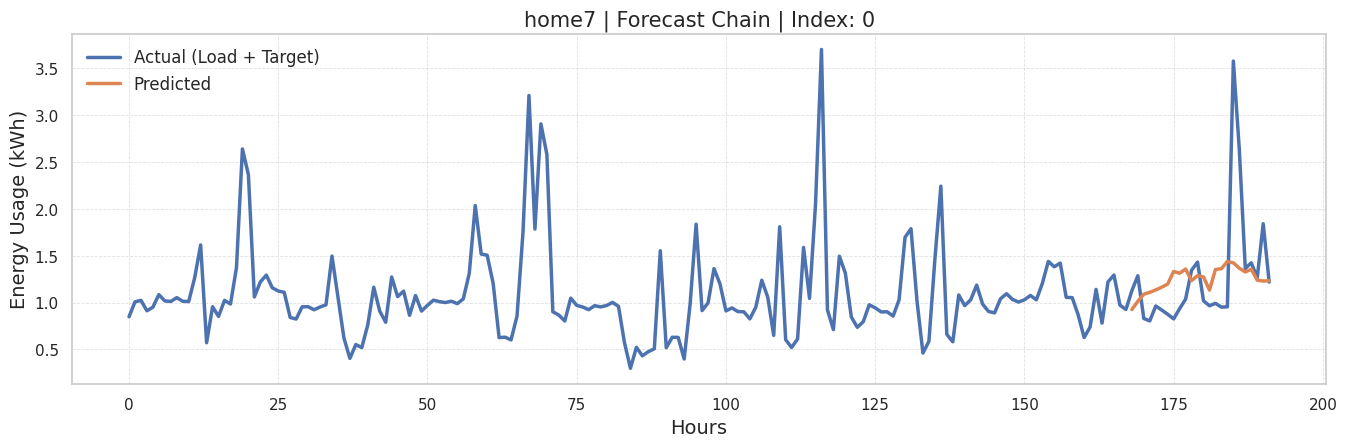

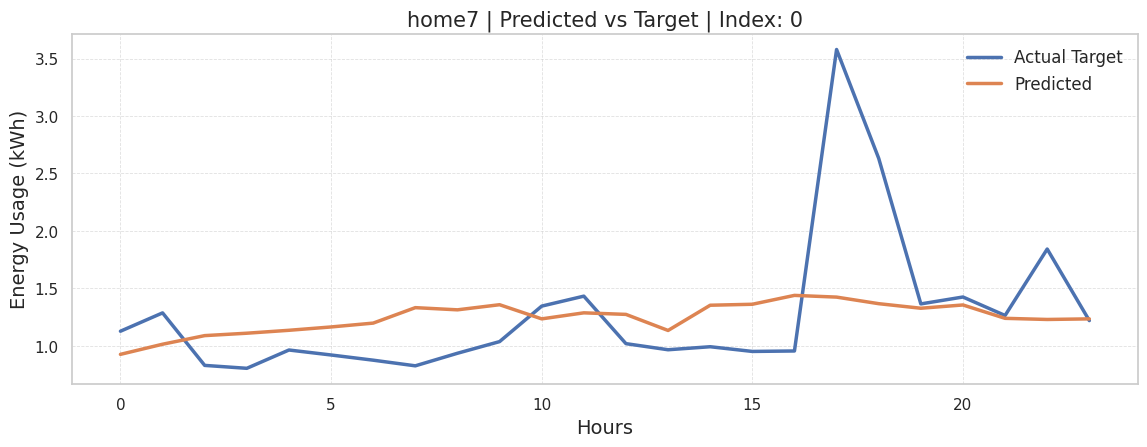

In [53]:
# ------------------- #
# ------ Edit ------- #
# ------------------- #

base_path = os.path.join(os.getcwd())
dataset = "borealis" # TODO: 
model = "LSTM" # TODO:
activation = "tanh" # TODO:
optimizer = "adam" # TODO:
epochs = "30" # TODO:
building_id = "home7" # TODO:
index = 0 # TODO:

plotter = ForecastPlotter(base_path, dataset, model, activation, optimizer, epochs)
plotter.get_num_forecast_indices(building_id)
plotter.plot_forecast_chain(building_id=building_id, index=index)
plotter.plot_predicted_vs_target_only(building_id=building_id, index=index)

# ------------------- #
# ------ Edit ------- #
# ------------------- #

## Task: Analysis

After generating all the plots, and based on the visualizations and metrics you have collected so far, please answer the following questions.

#### Best Performing Model

```
| Model  | Activation Function | Optimizer | Epochs | R² Score | MAE | MSE |
|--------|---------------------|-----------|--------|----------|-----|-----|
| NN     |                     |           |        |          |     |     |
| RNN    |                     |           |        |          |     |     |
| LSTM   |                     |           |        |          |     |     |
| GRU    |                     |           |        |          |     |     |
| MyNN   |                     |           |        |          |     |     |
```

1) Which model or models achieved the highest `R²` and the lowest `MAE` and `RMSE` scores?
2) How does your custom `MyNN` model compare to the other architectures in terms of evaluation metrics?
3) Which activation function and optimizer combination appears most frequently among the top-performing models?

```
### Training Time and Performance Metrics of Best Models

| Model  | Training Time (seconds)  | R² Score | MAE | MSE |
|--------|--------------------------|----------|-----|-----|
| NN     |                          |          |     |     |
| RNN    |                          |          |     |     |
| LSTM   |                          |          |     |     |
| GRU    |                          |          |     |     |
| MyNN   |                          |          |     |     |
```
1) Which model achieves the higest accuracy for least amount of time?
2) How does the training time of your custom `MyNN` model compare to the other architectures?

Considering the training time, evaluation metrics, and your own visualizations:
1) Which model would you consider the best overall?
2) Do you observe a clear trade-off between training time and evaluation metrics, where significant time savings can be achieved with only a minimal reduction in accuracy?

## Next Step: 

`/BuildingsBenchTutorial/Tutorials/Final-Project-Modules/Best-Overall-Model.md`